# E-commerce Data Exploration

In [2]:
# E-commerce Customer Behavior Analysis
# Exploratory Data Analysis Notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add project to path
sys.path.append(str(Path.cwd().parent))

from ecommerce_analysis.data_loader import load_raw_data
from ecommerce_analysis.data_cleaning import clean_data
from ecommerce_analysis.visualization import setup_plot_style

# Setup
setup_plot_style()
print("Setup complete!")

Setup complete!


## Load Raw Data

In [3]:
# Load the raw data
df_raw = load_raw_data()

# Display basic info
print(f"Shape: {df_raw.shape}")
print(f"\nFirst 5 rows:")
df_raw.head()

Shape: (541909, 8)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Initial Data Quality Assessment

In [4]:
# Missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
Description,1454,0.27
CustomerID,135080,24.93


##  Data Types and Statistics

In [5]:
# Data types
print("Data Types:")
print(df_raw.dtypes)

print("\n\nSummary Statistics:")
df_raw.describe()

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


Summary Statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## Quantity Distribution

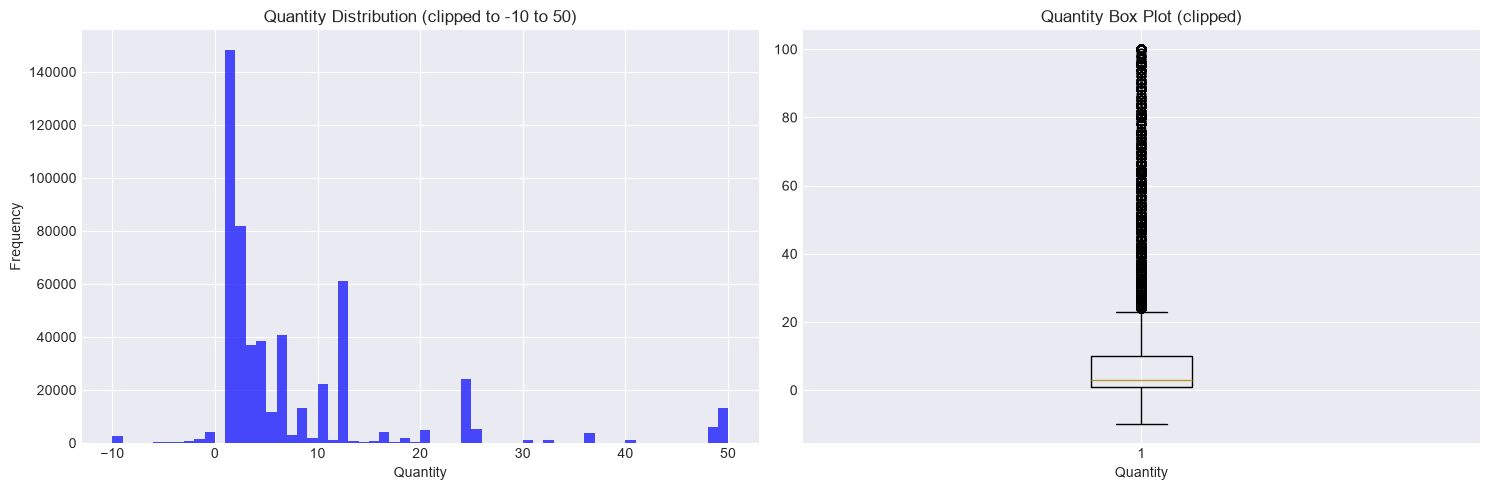

In [8]:
# Distribution of quantities
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram (zoomed to reasonable range)
axes[0].hist(df_raw['Quantity'].clip(-10, 50), bins=60, color='blue', alpha=0.7)
axes[0].set_title('Quantity Distribution (clipped to -10 to 50)')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df_raw['Quantity'].clip(-10, 100))
axes[1].set_title('Quantity Box Plot (clipped)')
axes[1].set_xlabel('Quantity')

plt.tight_layout()
plt.show()

## Unit Price Analysis

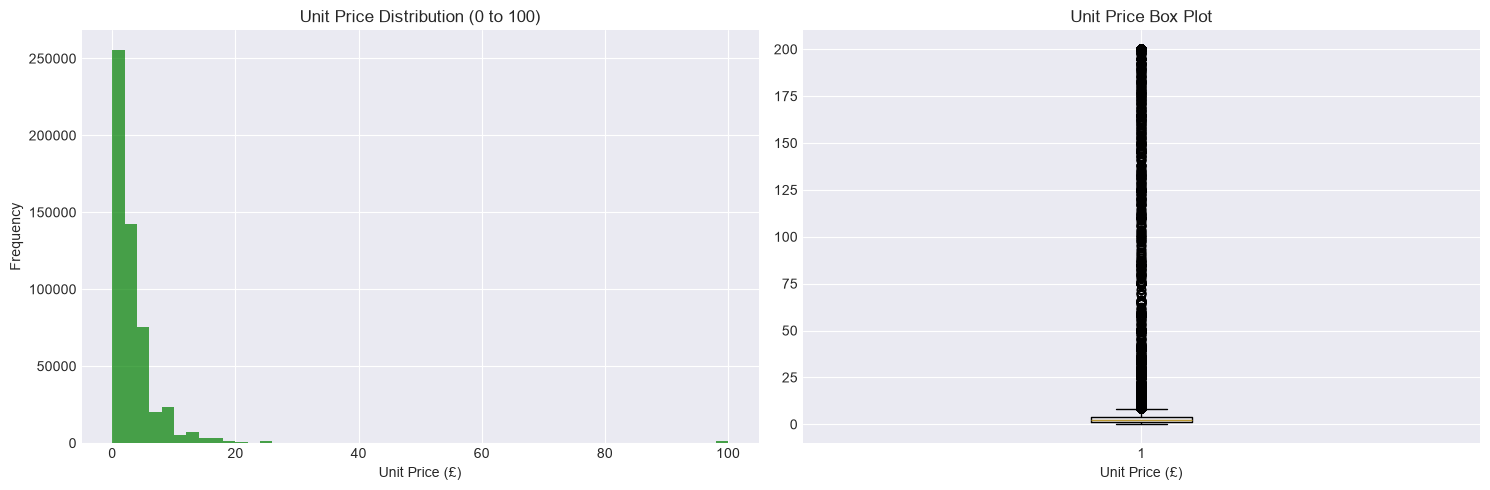

In [11]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram (zoomed)
axes[0].hist(df_raw['UnitPrice'].clip(0, 100), bins=50, color='green', alpha=0.7)
axes[0].set_title('Unit Price Distribution (0 to 100)')
axes[0].set_xlabel('Unit Price (£)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df_raw['UnitPrice'].clip(0, 200), orientation="vertical")
axes[1].set_title('Unit Price Box Plot')
axes[1].set_xlabel('Unit Price (£)')

plt.tight_layout()
plt.show()

## Country Distribution

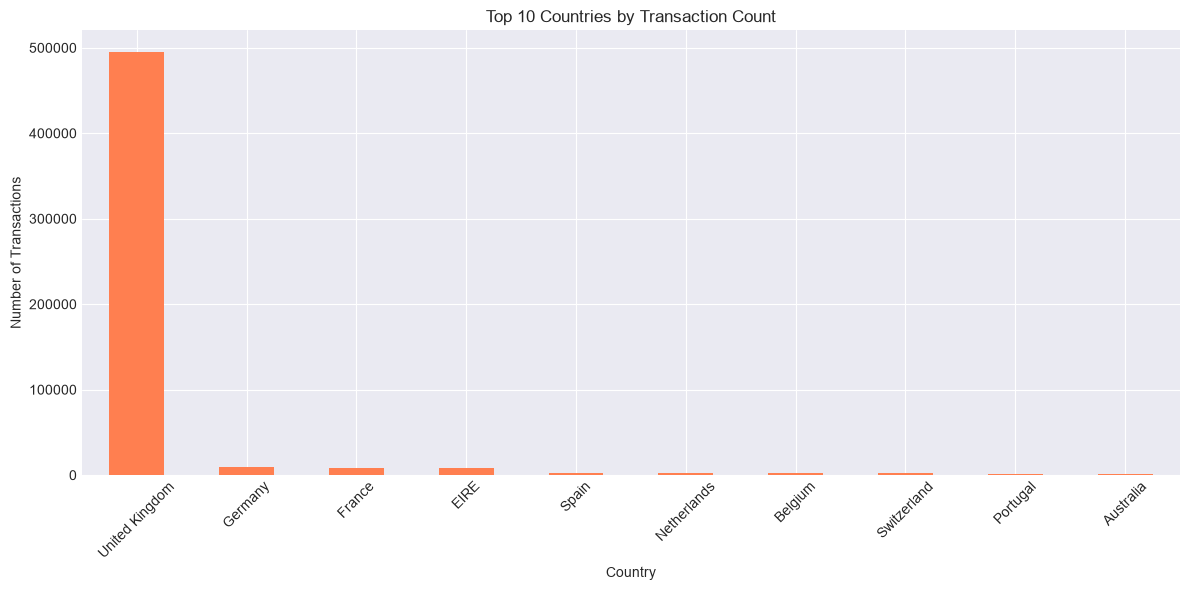

Top countries by transaction percentage:
  United Kingdom: 91.4%
  Germany: 1.8%
  France: 1.6%
  EIRE: 1.5%
  Spain: 0.5%


In [12]:
# Top countries by transactions
country_counts = df_raw['Country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
country_counts.plot(kind='bar', color='coral')
plt.title('Top 10 Countries by Transaction Count')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Percentage of total
country_pct = (country_counts / len(df_raw)) * 100
print("Top countries by transaction percentage:")
for country, pct in country_pct.head(5).items():
    print(f"  {country}: {pct:.1f}%")

## Time Series Analysis

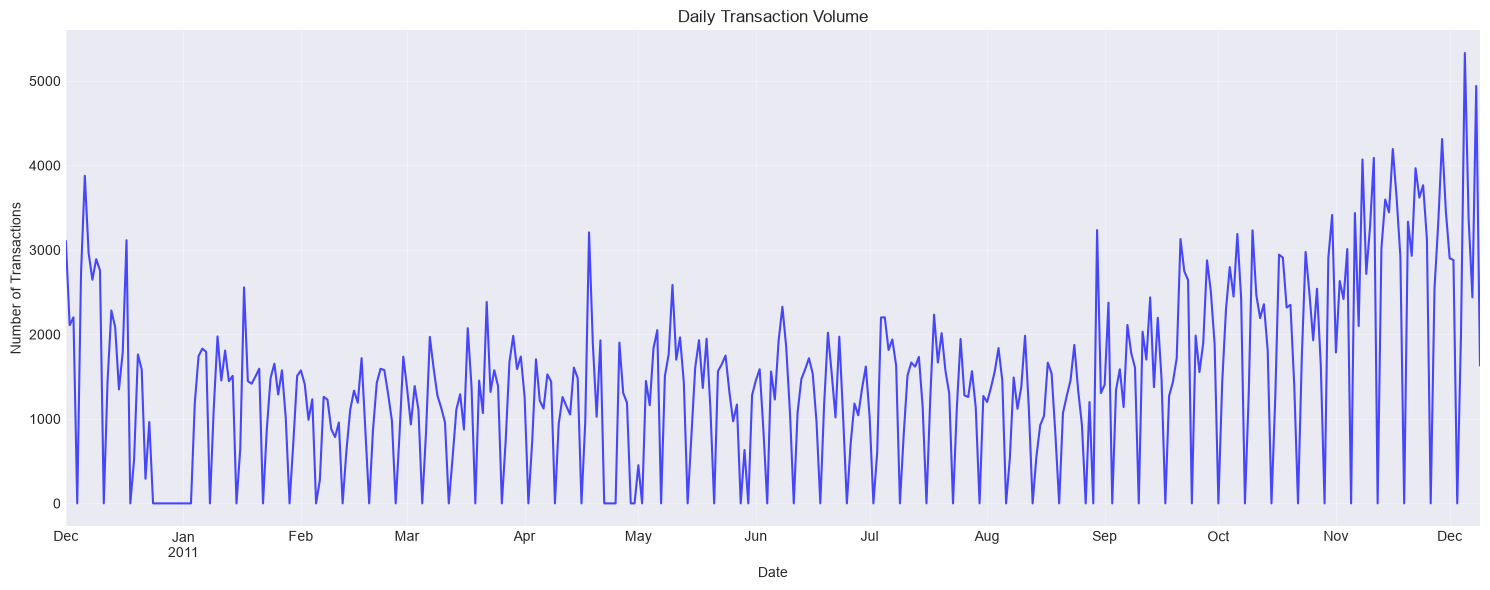

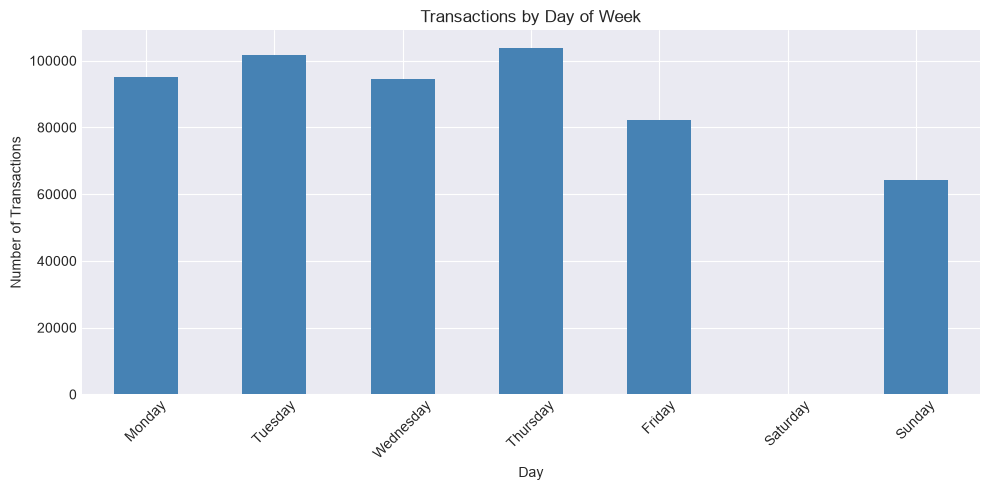

In [13]:
# Daily transaction volume
daily_transactions = df_raw.set_index('InvoiceDate').resample('D')['InvoiceNo'].count()

plt.figure(figsize=(15, 6))
daily_transactions.plot(color='blue', alpha=0.7)
plt.title('Daily Transaction Volume')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Weekly pattern
df_raw['DayOfWeek'] = df_raw['InvoiceDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df_raw['DayOfWeek'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='steelblue')
plt.title('Transactions by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Clean Data and Compare

In [14]:
# Clean the data
df_cleaned = clean_data(df_raw)

print(f"Raw data shape: {df_raw.shape}")
print(f"Cleaned data shape: {df_cleaned.shape}")
print(f"Rows removed: {len(df_raw) - len(df_cleaned):,} ({(1 - len(df_cleaned)/len(df_raw))*100:.1f}%)")

# Compare key statistics
comparison = pd.DataFrame({
    'Raw': [df_raw['Quantity'].sum(), df_raw['UnitPrice'].mean(), df_raw['TotalPrice'].sum() if 'TotalPrice' in df_raw.columns else 0],
    'Cleaned': [df_cleaned['Quantity'].sum(), df_cleaned['UnitPrice'].mean(), df_cleaned['TotalPrice'].sum()]
}, index=['Total Quantity', 'Avg Unit Price', 'Total Revenue'])

comparison

Raw data shape: (541909, 9)
Cleaned data shape: (401564, 11)
Rows removed: 140,345 (25.9%)


,Raw,Cleaned
Total Quantity,5.176450e+06,4.878967e+06
Avg Unit Price,4.611114e+00,3.474410e+00
Total Revenue,0.000000e+00,8.278519e+06


## Customer Analysis

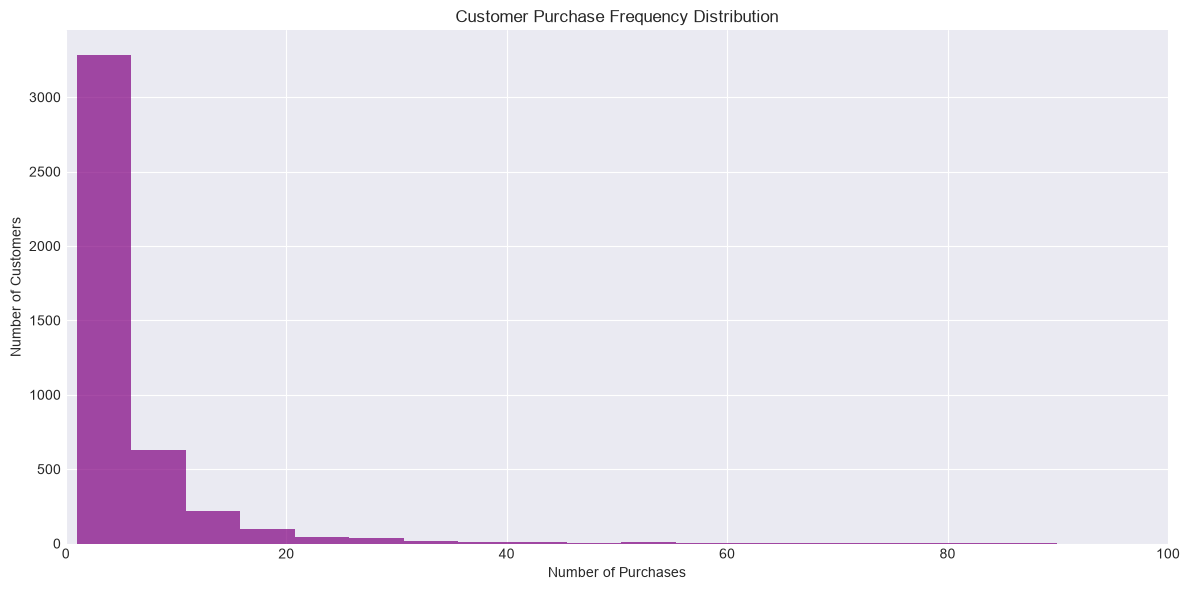

Average purchases per customer: 5.1
Median purchases per customer: 3


In [15]:
# Customer purchase frequency
customer_purchases = df_cleaned.groupby('CustomerID')['InvoiceNo'].nunique()

plt.figure(figsize=(12, 6))
plt.hist(customer_purchases, bins=50, color='purple', alpha=0.7)
plt.title('Customer Purchase Frequency Distribution')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.xlim(0, 100)  # Zoom to see most customers
plt.tight_layout()
plt.show()

print(f"Average purchases per customer: {customer_purchases.mean():.1f}")
print(f"Median purchases per customer: {customer_purchases.median():.0f}")

## Key Insights Summary

In [16]:
# Summary of findings
print("=" * 60)
print("KEY INSIGHTS FROM EDA")
print("=" * 60)

print(f"\n1. Data Quality:")
print(f"   - Raw transactions: {len(df_raw):,}")
print(f"   - Cleaned transactions: {len(df_cleaned):,}")
print(f"   - Data retention: {len(df_cleaned)/len(df_raw)*100:.1f}%")

print(f"\n2. Geographic Distribution:")
top_country = df_cleaned['Country'].value_counts().index[0]
top_country_pct = (df_cleaned['Country'].value_counts().iloc[0] / len(df_cleaned)) * 100
print(f"   - Dominant market: {top_country} ({top_country_pct:.1f}%)")

print(f"\n3. Customer Behavior:")
print(f"   - Unique customers: {df_cleaned['CustomerID'].nunique():,}")
print(f"   - Avg transactions per customer: {customer_purchases.mean():.1f}")

print(f"\n4. Products:")
print(f"   - Unique products: {df_cleaned['StockCode'].nunique():,}")
print(f"   - Avg items per transaction: {df_cleaned['Quantity'].mean():.1f}")

print("\n" + "=" * 60)

KEY INSIGHTS FROM EDA

1. Data Quality:
   - Raw transactions: 541,909
   - Cleaned transactions: 401,564
   - Data retention: 74.1%

2. Geographic Distribution:
   - Dominant market: United Kingdom (88.8%)

3. Customer Behavior:
   - Unique customers: 4,371
   - Avg transactions per customer: 5.1

4. Products:
   - Unique products: 3,684
   - Avg items per transaction: 12.1

